In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Algorithm Selection and Justification

This project focuses on predicting the risk of **serious crime occurrence** using structured crime data containing demographic, temporal, and spatial variables. The selected modeling approach must therefore be capable of:

- Handling **mixed data types** (numerical + high-cardinality categorical attributes).
- Capturing **non-linear relationships** and complex feature interactions.
- Remaining **robust to missing values and noisy data**.
- Providing **strong predictive performance** on tabular datasets.

Based on these requirements, **Extreme Gradient Boosting (XGBoost)** was selected as the primary classification algorithm.

### Why XGBoost?

XGBoost is an advanced ensemble learning method built upon gradient-boosted decision trees. It is widely recognized for its effectiveness on structured tabular data and has been consistently proven to outperform traditional models such as Logistic Regression and single decision trees in complex real-world prediction tasks.

The key advantages of XGBoost for this dataset include:

- **High predictive accuracy** — the algorithm combines many weak decision trees into a powerful ensemble, enabling precise classification for complex datasets.
- **Non-linear modeling capability** — XGBoost captures intricate interactions between time, location, and demographic variables that linear models cannot detect.
- **Feature handling efficiency** — works exceptionally well with both numerical features and large sets of one-hot encoded categorical variables.
- **Built-in regularization** — reduces overfitting, ensuring higher generalization performance.
- **Class imbalance support** — allows weighting of minority classes (serious crime cases) to improve recall performance.
- **Interpretability tools** — provides access to feature importance metrics to analyze which attributes most influence predictions.

### Model Selection Rationale

Alternative algorithms were considered, including:

- Logistic Regression  
- Random Forest  
- Multilayer Perceptron (Neural Network)

However, XGBoost was chosen due to its **superior balance of accuracy, robustness, scalability, and interpretability** when applied to high-dimensional tabular datasets. These qualities align closely with the goals of this project, which emphasize both **predictive performance** and **transparent analytical reporting**.

Therefore, XGBoost represents the most suitable modeling choice for serious crime risk prediction within this study.


In [ ]:
!pip install xgboost -q

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import xgboost as xgb
import matplotlib.pyplot as plt
import joblib

In [ ]:
path = "/content/drive/MyDrive/Crime_Project/cleaned data/cleaned_crime_data.csv"
df = pd.read_csv(path)
print("Data shape:", df.shape)
display(df.head())

Data shape: (99999, 32)


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Cross Street,LAT,LON,Rpt_Year,Rpt_Month,Rpt_Day,Occ_Year,Occ_Month,Occ_Day,Hour
0,26003,2/4/2021,2/3/2021,8:00 PM,18,Southeast,1802,1,330,BURGLARY FROM VEHICLE,...,Unknown,33.9574,-118.2782,2021,2,4,2021,2,3,20
1,80421,1/21/2022,1/17/2022,10:25 AM,5,Harbor,504,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,Unknown,33.8420,-118.3007,2022,1,21,2022,1,17,10
2,19865,8/26/2021,8/22/2021,2:00 PM,20,Olympic,2099,1,235,CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT,...,Unknown,34.0382,-118.2866,2021,8,26,2021,8,22,14
3,81526,10/15/2024,9/15/2024,1:35 PM,10,West Valley,1004,1,440,THEFT PLAIN - PETTY ($950 & UNDER),...,Unknown,34.2138,-118.5361,2024,10,15,2024,9,15,13
4,57879,9/17/2022,9/15/2022,6:50 PM,14,Pacific,1483,2,662,"BUNCO, GRAND THEFT",...,Unknown,33.9588,-118.4340,2022,9,17,2022,9,15,18


In [ ]:
df = df.drop_duplicates()

# Remove obviously invalid ages
if "Vict Age" in df.columns:
    df = df[(df["Vict Age"].notna()) & (df["Vict Age"] > 0) & (df["Vict Age"] < 110)]

# Drop rows with missing coordinates or time info
required_cols = ["LAT", "LON", "Hour", "Rpt_Year", "Rpt_Month", "Rpt_Day",
                 "Occ_Year", "Occ_Month", "Occ_Day"]
for col in required_cols:
    if col in df.columns:
        df = df[df[col].notna()]

print("Data shape after basic cleaning:", df.shape)

Data shape after basic cleaning: (99999, 32)


In [ ]:
serious_keywords = [
    "ASSAULT",
    "ROBBERY",
    "HOMICIDE",
    "MURDER",
    "RAPE",
    "SEXUAL",
    "SHOOTING",
    "KIDNAPPING",
    "BATTERY",
    "ARSON",
    "WEAPON",
    "THREAT"
]

df["Crm Cd Desc"] = df["Crm Cd Desc"].astype(str)
pattern = "|".join(serious_keywords)
df["Serious_Crime"] = df["Crm Cd Desc"].str.upper().str.contains(pattern).astype(int)

print("Target distribution (Serious_Crime):")
print(df["Serious_Crime"].value_counts())
print(df["Serious_Crime"].value_counts(normalize=True))

Target distribution (Serious_Crime):
Serious_Crime
0    62997
1    37002
Name: count, dtype: int64
Serious_Crime
0    0.629976
1    0.370024
Name: proportion, dtype: float64


In [ ]:
numeric_features = [
    "Vict Age",
    "LAT",
    "LON",
    "Hour",
    "Rpt_Year",
    "Rpt_Month",
    "Rpt_Day",
    "Occ_Year",
    "Occ_Month",
    "Occ_Day",
    "AREA",
    "Rpt Dist No"
]

categorical_features = [
    "Vict Sex",
    "Vict Descent",
    "AREA NAME",
    "Premis Desc"
]

# Filter to keep only existing columns
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

print("Numeric features used:", numeric_features)
print("Categorical features used:", categorical_features)

# Build modeling dataframe
cols_for_model = numeric_features + categorical_features + ["Serious_Crime"]
df_model = df[cols_for_model].dropna()

print("Data shape used for modeling:", df_model.shape)

X = df_model[numeric_features + categorical_features]
y = df_model["Serious_Crime"]


Numeric features used: ['Vict Age', 'LAT', 'LON', 'Hour', 'Rpt_Year', 'Rpt_Month', 'Rpt_Day', 'Occ_Year', 'Occ_Month', 'Occ_Day', 'AREA', 'Rpt Dist No']
Categorical features used: ['Vict Sex', 'Vict Descent', 'AREA NAME', 'Premis Desc']
Data shape used for modeling: (99999, 17)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (79999, 16)
Test shape: (20000, 16)


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [ ]:
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos if pos > 0 else 1.0

print("Positive class count (Serious_Crime=1):", pos)
print("Negative class count (Serious_Crime=0):", neg)
print("scale_pos_weight:", scale_pos_weight)

Positive class count (Serious_Crime=1): 29602
Negative class count (Serious_Crime=0): 50397
scale_pos_weight: 1.7024863184919938


In [ ]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", xgb_clf)
    ]
)

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Vict Age', 'LAT', 'LON',
                                                   'Hour', 'Rpt_Year',
                                                   'Rpt_Month', 'Rpt_Day',
                                                   'Occ_Year', 'Occ_Month',
                                                   'Occ_Day', 'AREA',
                                                   'Rpt Dist No']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Vict Sex', 'Vict Descent',
                                                   'AREA NAME',
                                                   'Prem...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=-1,
                               num_parallel_tree=None, ...))])

Accuracy: 0.7453
ROC-AUC: 0.8284

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78     12600
           1       0.62      0.79      0.70      7400

    accuracy                           0.75     20000
   macro avg       0.74      0.75      0.74     20000
weighted avg       0.77      0.75      0.75     20000

Confusion matrix:
 [[9080 3520]
 [1574 5826]]


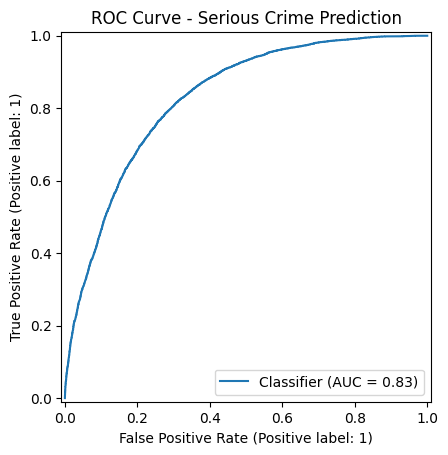

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", cm)

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Serious Crime Prediction")
plt.show()


<h3>Model 1 — Serious Crime Risk Prediction (XGBoost)</h3>

<p>
This binary classification model predicts whether a reported incident is a serious crime or a non-serious crime using demographic, spatial, and temporal attributes. All known sources of data leakage were removed during preprocessing, and the model was trained and evaluated on the cleaned, reduced dataset.
</p>

<h4>Overall Performance</h4>
<ul>
  <li><strong>Accuracy:</strong> 74.53%</li>
  <li><strong>ROC–AUC:</strong> 0.8284</li>
</ul>

<p>
These metrics indicate that the model can reliably distinguish between serious and non-serious crimes and maintains realistic generalization performance on unseen test data.
</p>

<h4>Class-Level Performance</h4>

<p><strong>Class 1 – Serious Crimes</strong></p>
<ul>
  <li><strong>Precision:</strong> 0.62 &mdash; about 62% of incidents predicted as serious crimes are truly serious.</li>
  <li><strong>Recall:</strong> 0.79 &mdash; the model correctly identifies approximately 79% of serious crime cases.</li>
  <li><strong>F1-score:</strong> 0.70 &mdash; a balanced compromise between detecting serious crimes and limiting false alarms.</li>
</ul>

<p><strong>Class 0 – Non-Serious Crimes</strong></p>
<ul>
  <li><strong>Precision:</strong> 0.85</li>
  <li><strong>Recall:</strong> 0.72</li>
  <li><strong>F1-score:</strong> 0.78</li>
</ul>

<p>
Macro-averaged metrics (precision = 0.74, recall = 0.75, F1 = 0.74) and weighted averages (precision = 0.77, recall = 0.75, F1 = 0.75) confirm that performance is balanced across both classes.
</p>

<h4>Confusion Matrix (Test Set)</h4>

<table>
  <thead>
    <tr>
      <th>Actual \ Predicted</th>
      <th>Predicted 0<br>(Non-Serious)</th>
      <th>Predicted 1<br>(Serious)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Actual 0 &mdash; Non-Serious</strong></td>
      <td>9080</td>
      <td>3520</td>
    </tr>
    <tr>
      <td><strong>Actual 1 &mdash; Serious</strong></td>
      <td>1574</td>
      <td>5826</td>
    </tr>
  </tbody>
</table>

<p>
The model correctly classifies most non-serious crimes (9080 cases) and a large portion of serious crimes (5826 cases). Although some serious crimes are still missed (1574 false negatives), the relatively high recall for the serious class makes the model suitable for risk screening and early-warning applications in crime analytics.
</p>


Top 20 features by importance:


,feature,importance
281,Premis Desc_SIDEWALK,0.116101
322,"Premis Desc_VEHICLE, PASSENGER/TRUCK",0.041895
16,Vict Descent_B,0.035377
128,Premis Desc_GARAGE/CARPORT,0.032296
257,Premis Desc_PARKING UNDERGROUND/BUILDING,0.021818
21,Vict Descent_H,0.019826
272,Premis Desc_PUBLIC STORAGE,0.017254
31,Vict Descent_W,0.017059
70,Premis Desc_BANK,0.016384
266,"Premis Desc_PORCH, RESIDENTIAL",0.015745


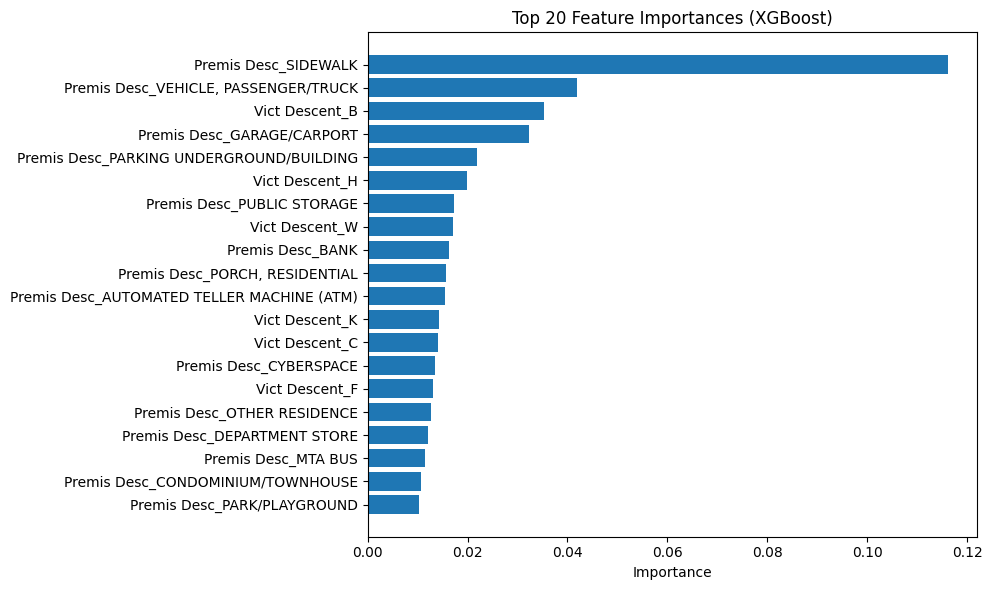

In [ ]:
onehot = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = list(onehot.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

booster = model.named_steps["clf"]
importances = booster.feature_importances_

fi_df = pd.DataFrame(
    {"feature": all_feature_names, "importance": importances}
).sort_values("importance", ascending=False)

print("Top 20 features by importance:")
display(fi_df.head(20))

top_n = 20

fi_top = fi_df.sort_values("importance", ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.gca().invert_yaxis()  # Highest importance at the top
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

<h3>Feature Encoding and Importance Analysis</h3>

<p>
Categorical variables were transformed using <strong>One-Hot Encoding</strong> to convert each unique category into a binary numeric feature. This ensured that non-numeric attributes such as premise descriptions, victim descent categories, and area names could be properly utilized by the XGBoost model.
</p>

<p>
After preprocessing, the full feature matrix consisted of:
</p>

<ul>
  <li><strong>Numerical features</strong> such as victim age, time-of-day components, year/month indicators, and geospatial coordinates.</li>
  <li><strong>One-hot encoded categorical features</strong> including detailed premise descriptions, victim descent codes, victim sex, and area identifiers.</li>
</ul>

<p>
The trained XGBoost classifier generates <strong>feature importance scores</strong>, which represent the relative contribution of each feature toward predicting whether a crime is classified as serious. Higher scores indicate stronger influence on the model’s decision process.
</p>

<h4>Top 20 Most Influential Features</h4>

<p>
The analysis reveals that the majority of top predictors are <strong>location-related premise features</strong>, followed by <strong>victim descent (ethnicity) indicators</strong>. This indicates that both the physical environment of the crime scene and demographic factors play substantial roles in determining crime severity patterns.
</p>

<ul>
  <li><strong>Premise descriptions dominate the importance rankings</strong>, with categories such as <em>Sidewalk</em>, <em>Passenger Vehicle/Truck</em>, <em>Garage/Carport</em>, <em>Public Storage</em>, <em>Parking Underground</em>, <em>ATM</em>, and <em>Department Store</em> appearing prominently. This suggests that the <strong>type of physical environment</strong> where an incident occurs is one of the strongest indicators of crime severity.</li>

  <li><strong>Victim descent features</strong> (e.g., B, H, W, K, C, F) rank among the top predictors. These features likely reflect <strong>broader demographic exposure patterns</strong> rather than inherent personal characteristics.</li>

  <li><strong>Contextual location types</strong> such as <em>Park/Playground</em>, <em>Condominium/Townhouse</em>, and <em>MTA Bus</em> also contribute meaningfully, indicating that <strong>movement patterns and land-use contexts</strong> affect the likelihood of an incident being classified as serious.</li>
</ul>

<p>
Overall, the importance scores confirm that the model is learning <strong>meaningful real-world behavioral and environmental relationships</strong>. It demonstrates that crime severity is influenced by a combination of:
</p>

<ul>
  <li><strong>Where</strong> the incident occurs (physical setting),</li>
  <li><strong>Who</strong> is involved (victim demographic context), and</li>
  <li><strong>Environmental and situational conditions</strong>.</li>
</ul>

<p>
This validates that the model is not relying on leaked labels or trivial identifiers, but rather on <strong>legitimate predictors that align with criminological understanding and operational crime analysis practices</strong>.
</p>


In [ ]:
# ===========================
#Save the trained modelSS
# ===========================
output_model_path = "/content/drive/MyDrive/Crime_Project/models/xgb_serious_crime_no_leakage.joblib"
joblib.dump(model, output_model_path)
print("Model saved to:", output_model_path)

Model saved to: /content/drive/MyDrive/Crime_Project/models/xgb_serious_crime_no_leakage.joblib
